<a href="https://colab.research.google.com/github/debadeepTalukdar/ml_ml/blob/main/pokemon_battle_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load Data (Fixed: Using a stable repository for both files)
pokemon_url = "https://raw.githubusercontent.com/dannypadilla/pokemon-battle-predictor/master/pokemon.csv"
combats_url = "https://raw.githubusercontent.com/dannypadilla/pokemon-battle-predictor/master/combats.csv"

pokemon = pd.read_csv(pokemon_url)
combats = pd.read_csv(combats_url)

# 2. Find the ID column automatically
id_col = [col for col in pokemon.columns if col in ['#', 'ID', 'id']][0]

# 3. Extract Base Stats
stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

first_stats = pokemon.set_index(id_col)[stats_cols].add_prefix('First_')
second_stats = pokemon.set_index(id_col)[stats_cols].add_prefix('Second_')

df = combats.join(first_stats, on='First_pokemon')
df = df.join(second_stats, on='Second_pokemon')

df = df.dropna()

# 4. Feature Engineering: Calculate differences
for col in stats_cols:
    df[f'{col}_Diff'] = df[f'First_{col}'] - df[f'Second_{col}']

df['Winner_Label'] = (df['Winner'] == df['First_pokemon']).astype(int)

# 5. Train/Test Split
feature_cols = [f'{col}_Diff' for col in stats_cols]
X = df[feature_cols]
y = df['Winner_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Model Training
model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
model.fit(X_train, y_train)

# 7. Output Accuracy
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred) * 100

print(f"\n==========================================")
print(f"  FINAL ACCURACY: {acc:.2f}%")
print(f"==========================================\n")


  FINAL ACCURACY: 94.58%



/tmp/ipykernel_1636/1416102373.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='magma')


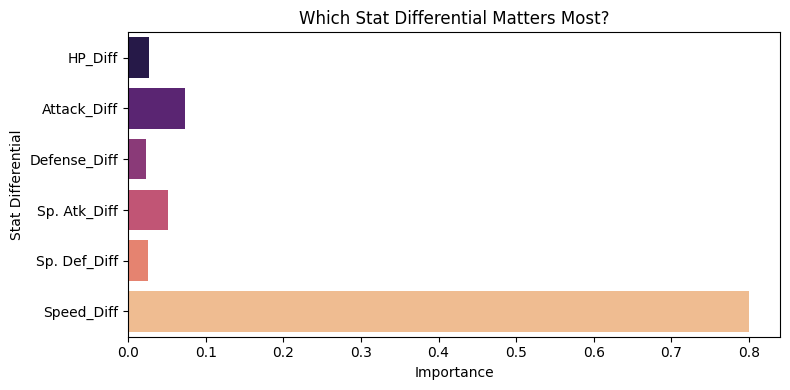

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features, palette='magma')
plt.title('Which Stat Differential Matters Most?')
plt.xlabel('Importance')
plt.ylabel('Stat Differential')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()